In [1]:
import cv2
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import PIL.Image

In [2]:
input_video_path = "two_channel.mp4"
output_csv_path = "double_results.csv"

In [3]:
# 1. Initialize Video Capture
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()
    
# aircraft parameters
rod_length_mm = 10.33  # mm

# List to store data for each frame
data_log = []

frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

display_every_n_frames = 10
cx = frame_width // 2
cy = frame_height // 2
window_size = 220

# Centered square crop window with bounds clamped to the frame
half_window = window_size // 2
x1 = cx - half_window
y1 = cy - half_window - 80
x2 = cx + half_window
y2 = cy + half_window - 80

# ROI (bottom-right of cropped frame)
roi_size = 50
prev_brightness = None
change_threshold = 10
brightness_frames = []



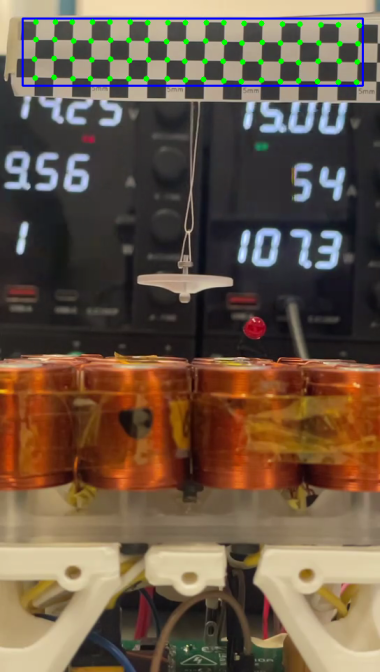

In [4]:
ret, frame = cap.read()
# cap.release() # Good practice to release if we only need one frame
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

grid_x1, grid_y1 = 32, 26
grid_x2, grid_y2 = 519, 122

gray_crop = gray[grid_y1:grid_y2, grid_x1:grid_x2]

# Detect corners directly as (x,y) coordinates
corners = cv2.goodFeaturesToTrack(gray_crop, maxCorners=300, qualityLevel=0.05, minDistance=15)
corners = corners.reshape(-1, 2)

# Adjust coordinates from the cropped image back to the original frame
corners[:, 0] += grid_x1
corners[:, 1] += grid_y1

tol = 15 # Pixel tolerance for alignment and boundary checking
mean_threshold = 10 # Threshold for identifying outliers in distance measurements

# 4. Calculate adjacent distances and track the points that created them
distances = []
point_pairs = []

for x, y in corners:
    # Find points to the right (lateral) and below (vertical) within alignment tolerance
    # We store a tuple of (distance, target_point) to track which point pairs match
    dx = [(c[0] - x, c) for c in corners if c[0] > x and abs(c[1] - y) < tol]
    dy = [(c[1] - y, c) for c in corners if c[1] > y and abs(c[0] - x) < tol]
    
    # Append the closest valid neighbor distance and record the point pair
    if dx:
        min_dx = min(dx, key=lambda item: item[0])
        distances.append(min_dx[0])
        point_pairs.append(((x, y), min_dx[1]))
        
    if dy:
        min_dy = min(dy, key=lambda item: item[0])
        distances.append(min_dy[0])
        point_pairs.append(((x, y), min_dy[1]))

# 5. Average the distances, filter outliers, and prepare visualization
if distances:
    distances_arr = np.array(distances)
    initial_mean = np.mean(distances_arr)
    
    # Create mask for valid distances
    valid_mask = np.abs(distances_arr - initial_mean) <= mean_threshold
    filtered_distances = distances_arr[valid_mask]
    
    if len(filtered_distances) > 0:
        avg_pixels = np.mean(filtered_distances)
        print(f"Prev Average Pixel Distance: {initial_mean:.2f} px")
        print(f"Average Pixel Distance: {avg_pixels:.2f} px")
        print(f"Conversion Ratio: {avg_pixels:.2f} pixels / 5mm")
        
        # Extract the points that belong to VALID distances
        valid_points = set()
        for i, is_valid in enumerate(valid_mask):
            if is_valid:
                p1, p2 = point_pairs[i]
                valid_points.add(tuple(p1))
                valid_points.add(tuple(p2))
                
        # --- VISUALIZATION ---
        
        # 1. Draw a blue rectangle to show the cropped ROI
        cv2.rectangle(frame, (grid_x1, grid_y1), (grid_x2, grid_y2), (255, 0, 0), 2)
        
        # 2. Draw all initially detected corners in red (optional context)
        for x, y in corners:
            cv2.circle(frame, (int(x), int(y)), 2, (0, 0, 255), -1)
            
        # 3. Overlay the valid (filtered) points in bright green (larger circles)
        for pt in valid_points:
            cv2.circle(frame, (int(pt[0]), int(pt[1])), 4, (0, 255, 0), -1)
            
        # Resize for display if the video is high resolution
        scale_percent = 70 
        width = int(frame.shape[1] * scale_percent / 100)
        height = int(frame.shape[0] * scale_percent / 100)
        resized_frame = cv2.resize(frame, (width, height), interpolation=cv2.INTER_AREA)

        img = PIL.Image.fromarray(cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)
        
    else:
        print("Error: No valid distances after filtering. Adjust 'mean_threshold'.")
else:
    print("Error: Not enough inner corners detected. Adjust 'tol' or qualityLevel.")

In [5]:
print(f"Prev Average Pixel Distance: {initial_mean:.2f} px")
print(f"Average Pixel Distance: {avg_pixels:.2f} px")

px_mm_ratio = avg_pixels / 5.0
print(f"Pixel-to-Millimeter Ratio: {px_mm_ratio:.2f} px/mm")


px_mm_ratio = 6.67


Prev Average Pixel Distance: 27.10 px
Average Pixel Distance: 27.10 px
Pixel-to-Millimeter Ratio: 5.42 px/mm


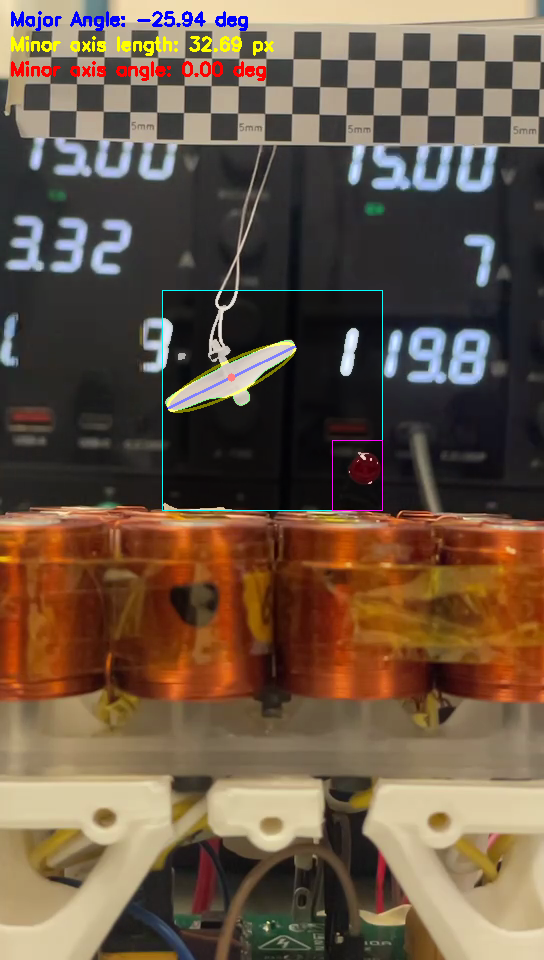

l0: 29.88 px | l: 32.85 px
Angle with X-Axis: -26.04 deg
Final Combined Angle: -26.04 deg
Frame 2641 | Major (2D): -26.04° | Minor (3D Tilt): 0.00°
l0: 29.88 px | l: 32.68 px
Angle with X-Axis: -26.00 deg
Final Combined Angle: -26.00 deg
Frame 2642 | Major (2D): -26.00° | Minor (3D Tilt): 0.00°
l0: 29.88 px | l: 31.62 px
Angle with X-Axis: -26.08 deg
Final Combined Angle: -26.08 deg
Frame 2643 | Major (2D): -26.08° | Minor (3D Tilt): 0.00°

Success! Data saved to: double_results.csv


In [6]:
import cv2
import numpy as np
import math
import pandas as pd
import PIL.Image
from IPython.display import display, clear_output

# Minor-axis tilt reference
l0 = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped = frame[y1:y2, x1:x2]
    
    # 1. Grayscale and basic threshold
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)
    
    # 2. ROI Brightness detection
    h, w = binary.shape[:2]
    rx1, ry1 = max(w - roi_size, 0), max(h - roi_size - 20, 0)
    current_brightness = cv2.mean(binary[ry1:h, rx1:w])[0]

    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)
    prev_brightness = current_brightness

    # 3. Disconnect thin strings/sticks using Morphological Opening
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13,13))
    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 4. Find contours and strictly keep only the largest one
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    frame_data = {
        "frame": frame_count, "timestamp_sec": frame_count / fps, "detected": False,
        "line_point_x": None, "line_point_y": None, "line_dir_x": None, "line_dir_y": None,
        "line_angle_deg_major": None, "line_angle_deg_minor": None, "longest_width_px": None,
        "contour_area_px": None, "final_combined_angle_deg": None
    }

    overlay = frame.copy()  # Draw on full frame instead of binary
    
    if contours:
        best_cnt = max(contours, key=cv2.contourArea)
        
        # Only process if the blob is substantial
        if cv2.contourArea(best_cnt) > 200:
            contour_fill_mask = np.zeros_like(gray)
            cv2.drawContours(contour_fill_mask, [best_cnt], -1, 255, cv2.FILLED)
            
            # Use filled outer contour area so inner holes do not shrink A at large tilt
            contour_area = float(np.count_nonzero(contour_fill_mask))
            frame_data["contour_area_px"] = round(contour_area, 2)

            y_idx, x_idx = np.nonzero(contour_fill_mask)
            pts = np.column_stack((x_idx, y_idx)).astype(np.float32)
            
            if len(pts) >= 10:
                # 5. PCA Analysis
                mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts, mean=None)
                cx_local, cy_local = mean[0, 0], mean[0, 1]
                
                # Primary eigenvector (major axis) directions
                vx, vy = eigenvectors[0, 0], eigenvectors[0, 1]
                
                # Calculate Major Angle (2D Roll/Yaw)
                angle_rad_major = math.atan2(vy, vx)
                angle_deg_major = math.degrees(angle_rad_major)
                
                # Project pixels onto eigenvectors to calculate EXACT tight bounds
                centered = pts - mean[0]
                proj_major = np.dot(centered, eigenvectors[0])
                proj_minor = np.dot(centered, eigenvectors[1])
                
                major_len = float(proj_major.max() - proj_major.min())
                # minor_len = float(proj_minor.max() - proj_minor.min())
                minor_len = math.fabs(2 * float(proj_minor.min()))

                # Initialize l0 from the first valid PCA minor-axis length
                if l0 is None and minor_len > 0:
                    l0 = float(minor_len)

                # PCA foreshortening tilt from minor axis: theta = acos(l / l0)
                ratio_minor = min(max(minor_len / l0, 0.0), 1.0) if l0 and l0 > 0 else 1.0
                angle_rad_minor = math.acos(ratio_minor)
                angle_deg_minor = math.degrees(angle_rad_minor)
                print(f"l0: {l0:.2f} px | l: {minor_len:.2f} px")
                
                # Normalize angles for readable output
                if angle_deg_major > 90: angle_deg_major -= 180
                elif angle_deg_major < -90: angle_deg_major += 180
                
                if angle_deg_minor > 90: angle_deg_minor -= 180
                elif angle_deg_minor < -90: angle_deg_minor += 180
                
                
                # Convert degrees to radians for Python's math library
                rad_major = math.radians(angle_deg_major)
                rad_tilt = math.radians(angle_deg_minor) 

                # 1. Corrected 3D angle with the horizontal left/right axis
                tan_alpha = math.tan(rad_major) * math.cos(rad_tilt)
                true_axis_angle = math.degrees(math.atan(tan_alpha))

                # 2. Combined final angle from azimuthal (major axis) and radial (area-based tilt)
                sin_beta = math.sin(rad_major) * math.cos(rad_tilt)
                final_combined_angle = math.degrees(math.asin(sin_beta))

                print(f"Angle with X-Axis: {true_axis_angle:.2f} deg")
                print(f"Final Combined Angle: {final_combined_angle:.2f} deg")
                
                
                # Convert local crop coordinates to full-frame coordinates
                cx_full = float(cx_local + x1)
                cy_full = float(cy_local + y1)
                
                frame_data.update({
                    "detected": True, "line_point_x": round(cx_full, 2), "line_point_y": round(cy_full, 2),
                    "line_dir_x": round(float(vx), 4), "line_dir_y": round(float(vy), 4),
                    "line_angle_deg_major": round(angle_deg_major, 2),
                    # "line_angle_deg_minor": round(angle_deg_minor, 2), 
                    # "true_axis_angle_deg": round(true_axis_angle, 2),
                    # "true_floor_angle_deg": round(final_combined_angle, 2),
                    "final_combined_angle_deg": round(final_combined_angle, 2),
                    "longest_width_px": round(major_len, 2)
                })

                # Print to console
                print(f"Frame {frame_count} | Major (2D): {angle_deg_major:.2f}° | Minor (3D Tilt): {angle_deg_minor:.2f}°")

                # --- Visualizations on full frame ---
                best_cnt_full = best_cnt.copy()
                best_cnt_full[:, :, 0] += x1
                best_cnt_full[:, :, 1] += y1
                cv2.drawContours(overlay, [best_cnt_full], -1, (0, 255, 0), 1)
                
                # Draw tight ellipse using PCA dimensions and oriented via the Major Angle
                rx, ry = int(major_len / 2), int(minor_len / 2)
                cv2.ellipse(overlay, (int(cx_full), int(cy_full)), (rx, ry), angle_deg_major, 0, 360, (0, 255, 255), 2)
                
                # Draw Central Axis Line
                L = major_len / 2
                pt1 = (int(cx_full - vx * L), int(cy_full - vy * L))
                pt2 = (int(cx_full + vx * L), int(cy_full + vy * L))
                cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
                cv2.circle(overlay, (int(cx_full), int(cy_full)), 4, (0, 0, 255), -1)
                
                # Display BOTH angles on the video frame
                cv2.putText(overlay, f"Major Angle: {angle_deg_major:.2f} deg", (10, 25), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                cv2.putText(overlay, f"Minor axis length: {minor_len:.2f} px", (10, 50), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                cv2.putText(overlay, f"Minor axis angle: {angle_deg_minor:.2f} deg", (10, 75), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Overlay the binary mask onto the full frame
    main_mask_bgr = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    if (y2 > y1) and (x2 > x1) and overlay[y1:y2, x1:x2].shape[:2] == main_mask_bgr.shape[:2]:
        overlay[y1:y2, x1:x2] = cv2.addWeighted(overlay[y1:y2, x1:x2], 0.5, main_mask_bgr, 0.5, 0)
    
    # Draw crop rectangle on full frame
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 0), 1)
    
    # Draw ROI rectangle on full frame
    roi_x1 = x1 + max(w - roi_size, 0)
    roi_y1 = y1 + max(h - roi_size - 20, 0)
    roi_x2 = x1 + w
    roi_y2 = y1 + h
    cv2.rectangle(overlay, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 0, 255), 1)
    
    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    # Visualization refresh
    if frame_count % display_every_n_frames == 0:
        img = PIL.Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

# Clean up and save results
cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nSuccess! Data saved to: {output_csv_path}")

Segment 0: Frames 578 to 798, Mean Angle: 4.63, Std: 0.64
Segment 1: Frames 838 to 977, Mean Angle: 3.30, Std: 0.49
Segment 2: Frames 1017 to 1155, Mean Angle: 1.87, Std: 1.23
Segment 3: Frames 1195 to 1334, Mean Angle: 0.08, Std: 0.60
Segment 4: Frames 1374 to 1512, Mean Angle: -2.86, Std: 1.55
Segment 5: Frames 1552 to 1693, Mean Angle: -5.51, Std: 2.51
Segment 6: Frames 1733 to 1872, Mean Angle: -7.17, Std: 1.37
Segment 7: Frames 1912 to 2051, Mean Angle: -10.88, Std: 1.87
Segment 8: Frames 2091 to 2231, Mean Angle: -13.78, Std: 4.18
Segment 9: Frames 2271 to 2410, Mean Angle: -18.93, Std: 2.38


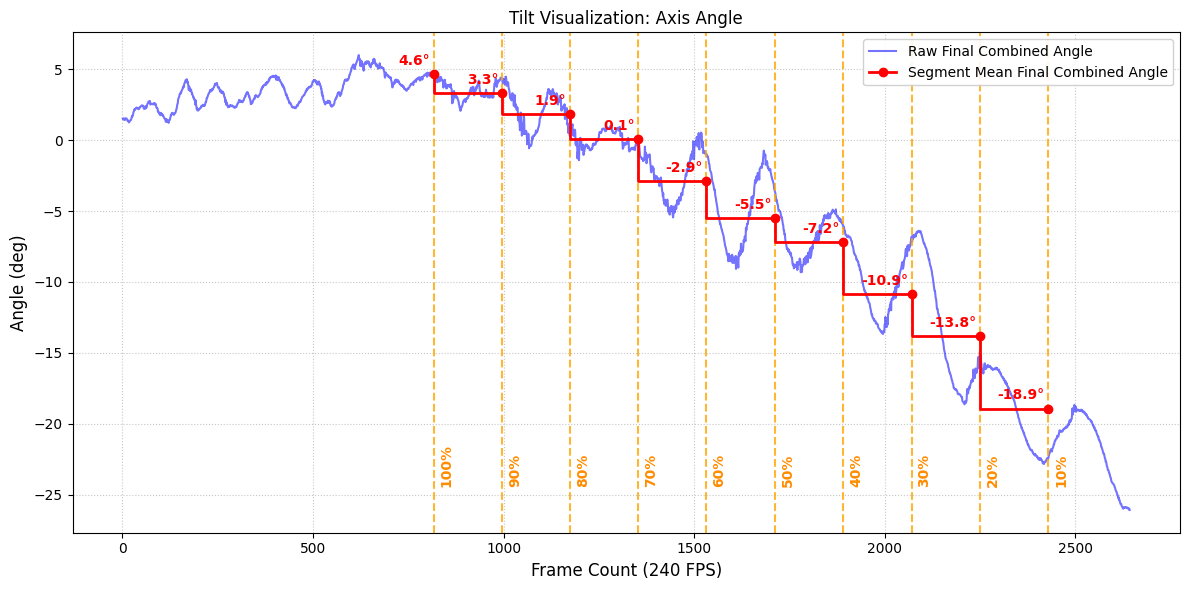

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and filter detections
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Plot the final combined angle (azimuthal major-axis + radial area-based tilt)
angle_col = 'final_combined_angle_deg' if 'final_combined_angle_deg' in df.columns else 'true_floor_angle_deg'

# Compute segment means robustly based on actual frame values
mean_segment_angles = []
segment_std_angles = []
segment_buffer = 20

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer

    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)][angle_col]
    mean_val = seg.mean()
    std_val = seg.std()
    mean_segment_angles.append(mean_val)
    segment_std_angles.append(std_val)
    print(f"Segment {i}: Frames {seg_start} to {seg_end}, Mean Angle: {mean_val:.2f}, Std: {std_val:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df['frame'], df[angle_col], 'b-', alpha=0.55, label='Raw Final Combined Angle')

y_min, y_max = df[angle_col].min(), df[angle_col].max()
y_range = y_max - y_min

for i, bt in enumerate(brightness_frames):
    plt.axvline(bt, color='orange', linestyle='--', alpha=0.8)
    percentage_str = f'{100 - i*10}%'
    plt.text(bt + 15, y_min + y_range * 0.05, percentage_str,
             color='darkorange', rotation=90, va='bottom', ha='left',
             fontweight='bold', fontsize=10)

plt.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre',
         linewidth=2, markersize=6, label='Segment Mean Final Combined Angle')

# Error bars from per-segment variance (std dev)
# plt.errorbar(brightness_frames, mean_segment_angles, yerr=segment_std_angles, fmt='none',
#              ecolor='black', elinewidth=1.2, capsize=3, alpha=0.9,
#              label='Segment Std Dev')

for bt, mean_angle in zip(brightness_frames, mean_segment_angles):
    if pd.notna(mean_angle):
        plt.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°",
                 color='red', fontweight='bold', fontsize=10, ha='right')

plt.title('Tilt Visualization: Axis Angle')
plt.xlabel('Frame Count (240 FPS)', fontsize=12)
plt.ylabel('Angle (deg)', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()
